# RCAP + Deletion/Insertion AUC Demo

This notebook evaluates XAI saliency maps using two complementary metrics:

| Metric | Description |
|--------|-------------|
| **RCAP** | Progressively recovers image from black; measures how quickly model confidence is restored |
| **DAUC** | Deletes most-salient pixels first; model confidence should drop fast (lower = better saliency) |
| **IAUC** | Inserts most-salient pixels first into blurred background; confidence should rise fast (higher = better) |
| **Overall AUC** | `IAUC - DAUC` — single combined score, higher is better |

## 1. Setup

In [1]:
import os
import urllib.request

import numpy as np
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

from mlxops_xai import (
    vanilla_gradient,
    guided_absolute_grad,
    integrated_gradients,
    blur_integrated_gradients,
)
from mlxops_xai.rcap import RCAP
from mlxops_xai.auc import AUC

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Load Model and Images

In [2]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

SAMPLES = {
    "tench":            "n01440764_tench.JPEG",
    "goldfish":         "n01443537_goldfish.JPEG",
    "golden_retriever": "n02099601_golden_retriever.JPEG",
    "elephant":         "n02504013_Indian_elephant.JPEG",
}

os.makedirs("demo_images", exist_ok=True)
images_pil = {}
BASE_URL = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/"
for name, fname in SAMPLES.items():
    path = os.path.join("demo_images", fname)
    if not os.path.exists(path):
        req = urllib.request.Request(BASE_URL + fname, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as resp, open(path, "wb") as f:
            f.write(resp.read())
    images_pil[name] = Image.open(path).convert("RGB")

input_tensor = torch.stack([preprocess(img) for img in images_pil.values()]).to(device)
sample_names = list(images_pil.keys())

with torch.no_grad():
    targets = model(input_tensor).argmax(dim=1)

print(f"Batch shape : {input_tensor.shape}")
print(f"Targets     : {targets.tolist()}")

Batch shape : torch.Size([4, 3, 224, 224])
Targets     : [0, 1, 207, 385]


## 3. Compute Saliency Maps

In [3]:
METHODS = {
    "Vanilla Gradient": (vanilla_gradient,          {}),
    "Guided Abs Grad":  (guided_absolute_grad,      {"num_samples": 10, "aggregation": "guided", "th": 0.7}),
    "Integrated Grad":  (integrated_gradients,      {"steps": 10, "trials": 3}),
    "Blur IG":          (blur_integrated_gradients, {"num_samples": 20}),
}

saliency_maps = {}
for name, (func, kwargs) in METHODS.items():
    print(f"  {name}...", end=" ", flush=True)
    saliency_maps[name] = func(model, input_tensor, targets, **kwargs).cpu()
    print("done")

  Vanilla Gradient... done
  Guided Abs Grad... done
  Integrated Grad... done
  Blur IG... done


## 4. RCAP Evaluation

`RCAP` follows the **torchmetrics** `Metric` API:
- **`update(model, batch, saliency_maps)`** — accumulates statistics for one batch
- **`compute()`** — aggregates all batches and returns scores
- **`reset()`** — clears state for the next epoch
- **`evaluate()`** — one-shot convenience: `update` + `compute` + `reset`

In [4]:
rcap_evaluator = RCAP(lower_bound=0.5, recover_interval=0.1)

# Split into two mini-batches to demonstrate the multi-batch update/compute pattern
batch_slices = [slice(0, 2), slice(2, 4)]

rcap_results = {}
for name, sal in saliency_maps.items():
    sal = sal.to(device)
    for s in batch_slices:
        rcap_evaluator.update(model, (input_tensor[s], targets[s]), sal[s])

    result = rcap_evaluator.compute()
    rcap_evaluator.reset()

    rcap_results[name] = result['overall_rcap']['RCAP']  # shape: (n_images,)
    print(f"{name:20s}  RCAP per image: {rcap_results[name].round(decimals=4)}")

Vanilla Gradient      RCAP per image: tensor([2.0000e-04, 7.0000e-04, 1.0000e-04, 2.0000e-04])
Guided Abs Grad       RCAP per image: tensor([2.1010e-01, 3.2080e-01, 2.1160e-01, 2.0000e-04])
Integrated Grad       RCAP per image: tensor([0.0125, 0.0013, 0.0007, 0.0027])
Blur IG               RCAP per image: tensor([0.0123, 0.0799, 0.0000, 0.0987])


## 5. Deletion / Insertion AUC Evaluation

`AUC` follows the same **torchmetrics** `Metric` API as `RCAP`:
- **`update(model, batch, saliency_maps)`** — accumulates deletion/insertion probabilities for one batch
- **`compute()`** — aggregates all batches and returns DAUC / IAUC scores
- **`reset()`** — clears state for the next epoch
- **`evaluate()`** — one-shot convenience: `update` + `compute` + `reset`

Key parameters:
- `percentages`: pixel-retention thresholds (default `[1, 0.8, 0.6, 0.4, 0.2]`)
- `sigma`: Gaussian blur sigma for insertion background (default `16`)

In [5]:
auc_evaluator = AUC(percentages=[1, 0.8, 0.6, 0.4, 0.2])

auc_results = {}
for name, sal in saliency_maps.items():
    sal = sal.to(device)
    for s in batch_slices:
        auc_evaluator.update(model, (input_tensor[s], targets[s]), sal[s])

    result = auc_evaluator.compute()
    auc_evaluator.reset()

    auc_results[name] = result
    print(f"{name:20s}  DAUC={result['DAUC']:.4f}  IAUC={result['IAUC']:.4f}")

Vanilla Gradient      DAUC=0.2404  IAUC=0.2525
Guided Abs Grad       DAUC=0.1448  IAUC=0.4511
Integrated Grad       DAUC=0.2000  IAUC=0.2208
Blur IG               DAUC=0.1163  IAUC=0.3286


## 6. Deletion / Insertion Curves

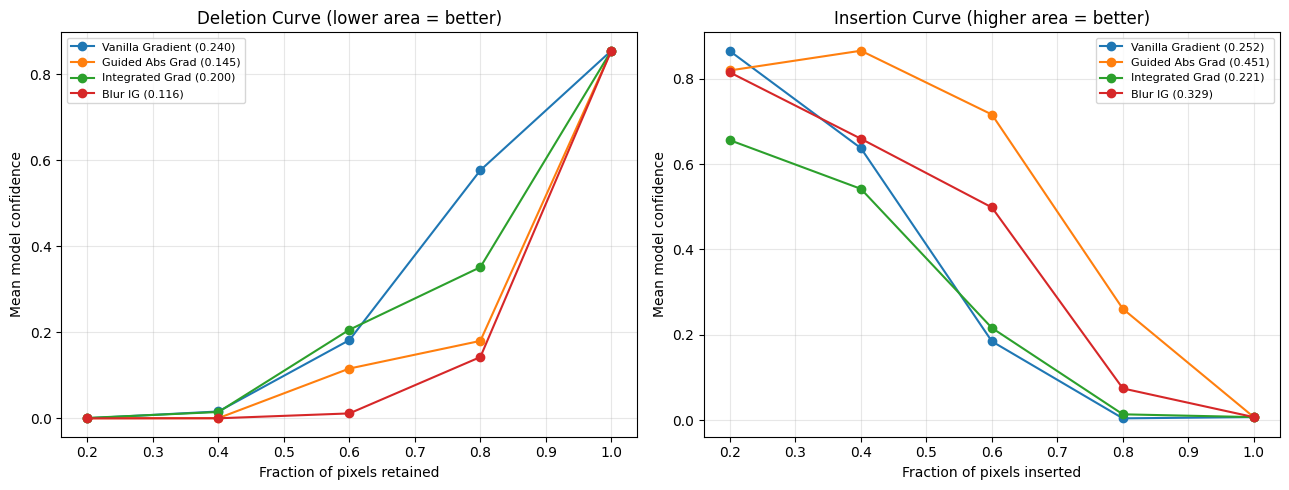

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, r in auc_results.items():
    x = r['AUC_Percentage']
    axes[0].plot(x, r['DAUC_arr'].mean(0), marker='o', label=f"{name} ({r['DAUC']:.3f})")
    axes[1].plot(x, r['IAUC_arr'].mean(0), marker='o', label=f"{name} ({r['IAUC']:.3f})")

axes[0].set_title("Deletion Curve (lower area = better)")
axes[0].set_xlabel("Fraction of pixels retained")
axes[0].set_ylabel("Mean model confidence")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Insertion Curve (higher area = better)")
axes[1].set_xlabel("Fraction of pixels inserted")
axes[1].set_ylabel("Mean model confidence")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. RCAP vs AUC Comparison

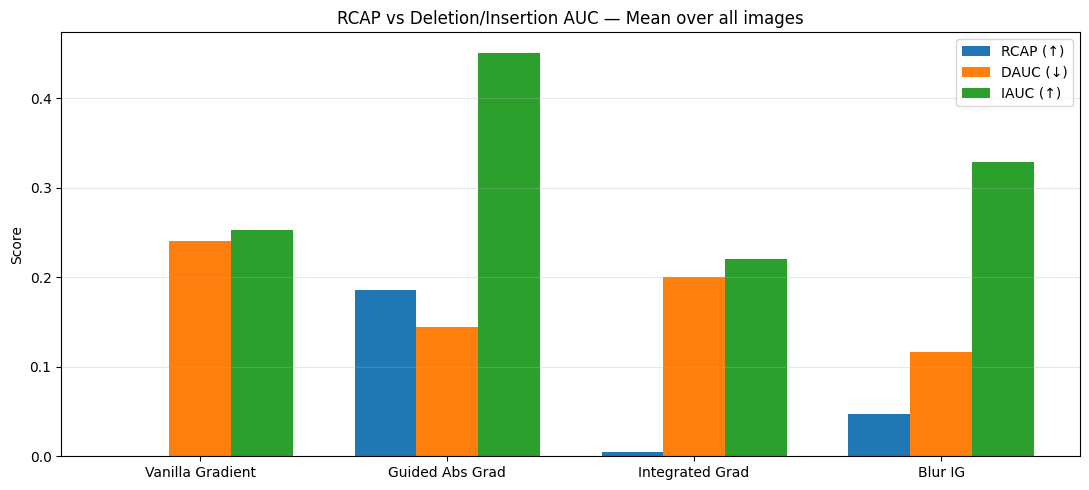

In [7]:
method_names = list(METHODS.keys())

mean_rcap = np.array([rcap_results[m].mean() for m in method_names])
mean_dauc = np.array([auc_results[m]['DAUC'] for m in method_names])
mean_iauc = np.array([auc_results[m]['IAUC'] for m in method_names])

x = np.arange(len(method_names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, mean_rcap, width, label="RCAP (↑)")
ax.bar(x,         mean_dauc, width, label="DAUC (↓)")
ax.bar(x + width, mean_iauc, width, label="IAUC (↑)")

ax.set_xticks(x)
ax.set_xticklabels(method_names)
ax.set_ylabel("Score")
ax.set_title("RCAP vs Deletion/Insertion AUC — Mean over all images")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()